In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from dotenv import load_dotenv
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# nltk.download("stopwords", quiet=True)
load_dotenv()
PPATH = os.getenv("PPATH")
COLOR = os.getenv("COLOR")

print(PPATH)

/Users/daragama/Documents/ProyectosVarios/Datathon2026/


In [3]:
df = pd.read_csv(PPATH + "data/hey_clientes.csv")
print(df.shape)
df.head()
df.columns

(15025, 22)


Index(['user_id', 'edad', 'sexo', 'estado', 'ciudad', 'nivel_educativo',
       'ocupacion', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro',
       'nomina_domiciliada', 'canal_apertura', 'score_buro',
       'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10',
       'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro',
       'num_productos_activos', 'patron_uso_atipico'],
      dtype='str')

satisfaccion_1_10
3.0      442
4.0      857
5.0      821
6.0     1691
7.0     3245
8.0     2420
9.0     2358
10.0    2440
Name: count, dtype: int64
7.475269721171361


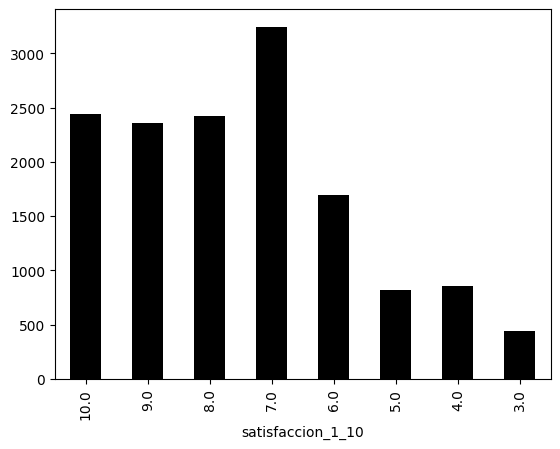

In [13]:
# sort by satisfaccion_1_10
print(df.value_counts("satisfaccion_1_10").sort_index())
df.value_counts("satisfaccion_1_10").sort_index(ascending=False).plot(kind="bar", color=COLOR)

# satisfaccion mean
print(df["satisfaccion_1_10"].mean())

In [5]:
df_productos = pd.read_csv(PPATH + "data/hey_productos.csv")
print(df_productos.shape)
df_productos.head()
df_productos.columns

(38909, 13)


Index(['producto_id', 'user_id', 'tipo_producto', 'fecha_apertura', 'estatus',
       'limite_credito', 'saldo_actual', 'utilizacion_pct',
       'tasa_interes_anual', 'plazo_meses', 'monto_mensualidad',
       'fecha_ultimo_movimiento', 'es_dato_sintetico'],
      dtype='str')

In [ ]:
# join df and df_productos on user_id
df_merged = pd.merge(df, df_productos, on="user_id", how="inner")
print(df_merged.shape)


(38909, 34)


,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,fecha_apertura,estatus,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,es_dato_sintetico
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
1,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,2022-10-16,activo,144000.0,88790.40,0.6166,35.71,NaN,NaN,2025-09-17,True
2,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,2025-04-03,activo,NaN,20712.54,NaN,NaN,NaN,NaN,2025-10-16,True
3,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,2025-07-18,activo,22000.0,6122.60,0.2783,34.08,NaN,NaN,2025-09-15,True
4,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,...,2023-03-26,activo,NaN,3454.65,NaN,NaN,NaN,NaN,2025-09-27,True


In [ ]:
df_reduced = df_merged[["user_id", "product_group", "satisfaccion_1_10", "es_hey_pro", "estatus", "limite_credito", "saldo_actual", ]]